# Loss functions for classification

# Binary Cross-Entropy (BCE) Loss

Binary Cross-Entropy Loss (also known as **Log Loss**) is the standard loss function used for **binary classification** tasks—where the model must classify an input into one of exactly two classes (e.g., Spam vs. Not Spam, or Outlier vs. Inlier).


## 1. The Mathematical Formula

For a single data point, the Binary Cross-Entropy loss is calculated as:

$$L(y, \hat{y}) = - \left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right]$$

When calculating the total **Cost Function** over an entire dataset of $n$ samples, we take the average:

$$J(w, b) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Where:
* keep in mind in ML or Data Science we take the base for log as **2.71** which is Eulor's number.
* $y$ is the true actual label (strictly either `0` or `1`).
* $\hat{y}$ is the model's predicted probability that the sample belongs to class `1` (a decimal between `0.0` and `1.0`, usually output by a **Sigmoid** activation function).


## 2. How the Formula Works Intuitively

Because the true label $y$ can only be `0` or `1`, the piecewise nature of the formula cancels out half of the equation dynamically for every calculation:

* **When the true label is $y = 1$:** The right side of the equation $(1 - y)$ becomes `0`, completely wiping out the second term. The loss simplifies to:
  $$Loss = - \log(\hat{y})$$
  * *Behavior:* If the model predicts a high probability close to `1.0`, the loss approaches `0`. If the model confidently predicts `0.0`, the loss explodes toward infinity.

* **When the true label is $y = 0$:** The left side of the equation vanishes because $y = 0$. The loss simplifies to:
  $$Loss = - \log(1 - \hat{y})$$
  * *Behavior:* If the model predicts a low probability close to `0.0`, the loss approaches `0`. If the model incorrectly predicts a high probability close to `1.0`, the penalty shoots up exponentially.

[Image of binary cross entropy loss function graph for y=1 and y=0]


## 3. Pros and Cons

### **Pros**
* **Heavy Penalty for High Confidence Errors:** Because of the logarithmic scale, if a model predicts a probability of `0.99` for a sample that is actually class `0`, it is penalized heavily. This strongly discourages dangerous, overly-confident wrong predictions.
* **Clean Gradients with Sigmoid:** When paired with a Sigmoid activation function, the mathematics of the derivative simplifies beautifully during backpropagation. The logs cancel out the "saturation" effect of Sigmoid, preventing gradients from vanishing when the model starts learning.
* **Direct Probability Outputs:** The loss function naturally trains the model to output a true probabilistic confidence interval (`0%` to `100%`) rather than a hard binary gate.

### **Cons**
* **Extremely Vulnerable to Mislabeled Data:** If an entry in your dataset is mislabeled (e.g., a true `1` is accidentally typed as a `0`), the model will face an near-infinite penalty if it correctly identifies the underlying pattern. This can completely destabilize gradient descent updates.
* **Sensitivity to Class Imbalance:** If your dataset contains 99% class `0` and only 1% class `1`, the model can achieve a very low cost simply by predicting `0` for everything. (To fix this, scientists must upgrade to *Weighted Binary Cross-Entropy*).
* **Prone to Undefined Values ($\log(0)$):** If a model predicts an absolute, perfect probability of `0.0` or `1.0`, computing $\log(0)$ will return an error or `NaN` (Not a Number). In code execution, a tiny buffer (like $10^{-7}$) must be added to prevent software


## How the entire formula works 
### **Step A: Linear Combination (Generating the Logit)**
The model multiplies incoming data by its architectural weights and adds a bias term. This results in a raw, unconstrained score called a **Logit ($z$)**.
* **Data Type:** `float`
* **Mathematical Range:** $(-\infty, +\infty)$
* **Formula:** $$z = \sum(\text{inputs} \times \text{weights}) + \text{bias}$$

### **Step B: Activation Function (Generating the Probability)**
Because a raw real number (like `4.2` or `-1.5`) cannot be interpreted as a probability, the logit is passed through the **Sigmoid function**. Sigmoid squashes the infinite range into a smooth decimal curve.
* **Data Type:** `float` ($\hat{y}$)
* **Mathematical Range:** $(0.0, 1.0)$
* **Formula:** $$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

### **Step C: Loss Evaluation (Measuring the Error)**
Once the model has generated its float probability ($\hat{y}$), it plugs that value along with the ground truth target label ($y$, which is a hard integer `0` or `1`) into the **Binary Cross-Entropy (BCE)** loss function to measure its error.
* **Data Type:** `float`
* **Mathematical Range:** $[0.0, +\infty)$
* **Formula:** $$L(y, \hat{y}) = - \left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right]$$


## 2. Why Tanh Cannot Be Used at the Output Layer

While **Tanh** is a powerful activation function for intermediate hidden layers, it is mathematically incompatible with the final layer of a Binary Cross-Entropy pipeline:

* **Sigmoid Range:** Outputs values between `0.0` and `1.0`. This aligns perfectly with probability theory and the mathematical constraints of the standard $\log(x)$ function in BCE.
* **Tanh Range:** Outputs values between `-1.0` and `+1.0`. Because probabilities cannot be negative, and computing the logarithm of a negative number ($\log(-0.5)$) is mathematically undefined, passing Tanh outputs directly into BCE will cause runtime crashes (`NaN` errors).

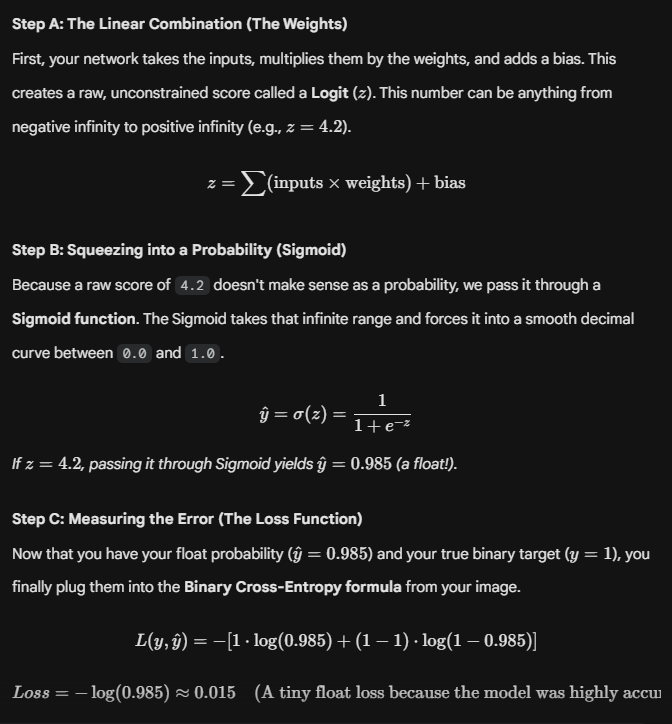



---

###  How binary cross entropy is different from setting normal thershold after the sigmoid, why i mean i can do prediction only to the sigmoid level ?

When your model is fully trained and running in production, you do not use Binary Cross-Entropy. You completely stop at the Sigmoid layer and just use a simple threshold (like if y_hat >= 0.5) to get your final 1 or 0 decision.

However, you cannot use that simple threshold method to train the model.

Here is exactly why we desperately need Binary Cross-Entropy during training instead of just using a threshold right after the Sigmoid:

1. **The Core Problem: Thresholds Break Calculus (Zero Gradients)**<br>
To train a neural network, we use gradient descent. Gradient descent relies on calculating partial derivatives (the slope) to figure out how to tweak the weights.

If you use a hard threshold gate like 1 if y_hat >= 0.5 else 0, you are creating a mathematical step function.

Look at the calculus of a threshold function:

- If the probability changes from 0.6 to 0.7, the threshold output stays exactly 1. The change is 0.
- If the probability changes from 0.2 to 0.3, the threshold output stays exactly 0. The change is 0.

**Because the output doesn't change smoothly, the derivative (slope) of a threshold function is exactly 0 everywhere. When backpropagation multiplies a 0 slope through the chain rule, your weight updates become exactly 0. Your network completely freezes and can never learn.**
<br><br>

2. **Binary Cross-Entropy Provides a "Mathematical Slide"**<br>
Binary Cross-Entropy (BCE) replaces that harsh, flat step function with a smooth, continuous logarithmic curve.

Instead of just checking if the model crossed a pass/fail line, BCE measures how confident or unconfident the model is.

- With a Threshold: If the true label is 1, a prediction of 0.51 and a prediction of 0.99 are treated exactly the same (both pass). The model receives no incentive to get better.
- With BCE Loss: A prediction of 0.51 yields a high loss (around 0.67), while a prediction of 0.99 yields a tiny loss (around 0.01).

Because the loss is a smooth curve, it has a measurable slope (gradient) at every single decimal point. This slope acts like a slide, giving gradient descent a clear directional path to roll down so it can continuously adjust the weights until the predictions are nearly perfect.

### If it just predicts the confidence in ans, then how come it classifies the ans ???

**Machine learning models never actually classify anything.**

At their core, neural networks are just massive calculators. They do not understand categories like "Spam" or "Not Spam"; they only compute continuous numbers (probabilities) based on matrix multiplications.

The actual act of "classification" is an illusion handled entirely by a simple threshold rule that you apply at the very end of the process.

1. **The Model Only Does the Scale, You Draw the Line**<br>
Think of the neural network as a smart scale. If you feed it an image of a handwritten digit, it doesn't shout "That's a number 7!" Instead, it outputs a raw confidence float, like 0.88.

To turn that continuous confidence score into a distinct, hard decision, you apply a deterministic boundary line (a threshold) in your regular Python code outside of the neural network:


```python
y_hat = 0.88  

# YOU perform the actual classification step here:
if y_hat >= 0.5:
    final_decision = "Class 1 (Spam)"
else:
    final_decision = "Class 0 (Not Spam)"
```
The model simply calculates the position on a scale from 0.0 to 1.0. The conditional if/else statement is what converts that fluid scale into a solid binary category.

---

#### **Why Choose 0.5? (And Why Scientists Change It)**<br>
By default, we set the classification threshold at 0.5 because it splits the probability scale right down the middle. If the model is more than 50% confident that an email is spam, it gets classified as spam.

However, because the model outputs a confidence score rather than a hard choice, data scientists can dynamically shift this threshold line depending on real-world stakes:

**Scenario A: Medical Diagnosis (Lowering the Threshold)**<br>
Imagine a model predicting whether a patient has a highly contagious disease.

- If the model outputs a confidence score of 0.25 (25% chance), using a standard 0.5 threshold would classify the patient as "Healthy."
- That is incredibly dangerous. In this case, scientists might shift the classification threshold down to 0.10. If the model is even 10% confident there is a risk, it flags it as a 1 so a human doctor can run a manual check.

**Scenario B: Criminal Justice or Strict Spam Filtering (Raising the Threshold)**<br>
Imagine a model predicting whether a user profile is fraudulent before deleting it.

- False alarms ruin user trust. You only want to delete an account if you are absolutely certain.
- In this case, scientists raise the classification threshold to 0.95. The model must output a confidence score of 95% or higher before the code executes a hard 1 to ban the account.





---

### Why cant we take the float from sigmoid as confidence ?

#### 1. The Direct Answer

We **do** take the raw floating-point value from the Sigmoid function as our confidence score. In fact, that is its exact definition during the deployment phase of a machine learning model.

* If Sigmoid outputs **$\hat{y} = 0.94$**, the model is mathematically $94\%$ confident the input belongs to Class 1.
* If Sigmoid outputs **$\hat{y} = 0.03$**, the model is mathematically $3\%$ confident it belongs to Class 1 (meaning it is $97\%$ confident it belongs to Class 0).

The confusion arises because we must separate **how we interpret the output during production** from **how calculus uses that output during training**.


#### 2. Why the Raw Float Fails During Training

During the training phase, our goal is to compute an error score (Loss) that generates steep mathematical gradients to update the network's weights via backpropagation. If you try to calculate error using *only* the raw Sigmoid float, the optimization mechanics break down.

##### **The Failure of Linear Distance ($\text{Loss} = y - \hat{y}$)**
Imagine your model processes an entry that is **definitely Spam ($y = 1$)**, but the network performs terribly and outputs a **Sigmoid float of $\hat{y} = 0.001$** ($0.1\%$ confidence).

If you compute a basic linear error:
$$\text{Loss} = 1 - 0.001 = 0.999$$

While `0.999` correctly indicates a large error, the mathematical derivative (the slope) of a basic linear line is a **flat constant**. 
* A flat constant slope means that whether the model makes a mild mistake ($\hat{y} = 0.4$) or a catastrophic, highly-confident mistake ($\hat{y} = 0.000001$), the weight adjustment step size remains exactly the same. 
* The network lacks the urgency to recover rapidly from dangerous, confident errors, causing training to stall out for millions of iterations.

#### 3. How Binary Cross-Entropy Acts as a Scaling Lens

Binary Cross-Entropy (BCE) resolves this by wrapping that raw Sigmoid confidence float inside a **negative logarithm ($-\log(\hat{y})$)**. The logarithm acts as a non-linear amplifier for errors, scaling the severity of the penalty exponentially based on how confidently wrong the model is.



##### **The Penalty Acceleration Breakdown (Given True Label $y = 1$)**

| Model Sigmoid Output ($\hat{y}$) | Real-World Translation | Calculated BCE Loss ($-\log(\hat{y})$) | Gradient Urgency |
| :--- | :--- | :--- | :--- |
| **$\hat{y} = 0.99$** | "Highly confident and correct." | $-\log(0.99) = \mathbf{0.01}$ | Near zero (leave weights alone) |
| **$\hat{y} = 0.50$** | "Completely uncertain / guessing." | $-\log(0.50) = \mathbf{0.69}$ | Moderate slope (smoothly tune weights) |
| **$\hat{y} = 0.01$** | "Confident mistake." | $-\log(0.01) = \mathbf{4.60}$ | Steep slope (aggressively shift weights) |
| **$\hat{y} = 0.00001$**| "Catastrophic, stubborn mistake."| $-\log(0.00001) = \mathbf{11.51}$| Explosive slope (force massive corrections) |



---

# How entire Backpropagation Works with respect to Binary Cross-Entropy (BCE) ???

To see how backpropagation actually works after calculating the Binary Cross-Entropy (BCE) loss, we have to look at the calculus happening behind the scenes.

Backpropagation moves backward through the network, using the **Chain Rule** to find exactly how much each weight and bias contributed to the final error. The ultimate goal is to find the gradient of the loss with respect to a weight ($\frac{\partial L}{\partial w}$), which tells the model how to adjust that weight to reduce the error.

Let's look at how the math unfolds backward through a single output neuron, reversing the forward pass pipeline we established.

### Step 1: Loss to Prediction ($\frac{\partial L}{\partial \hat{y}}$)

First, the algorithm looks at the final BCE loss value and asks: *"If the predicted probability ($\hat{y}$) changes slightly, how much does the loss ($L$) change?"*

Taking the partial derivative of the BCE formula gives us this fractional rate of change:

$$ \frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})} $$

### Step 2: Prediction to Logit ($\frac{\partial \hat{y}}{\partial z}$)

Next, the algorithm steps backward through the Sigmoid activation function to ask: *"If the raw logit score ($z$) changes slightly, how much does the predicted probability ($\hat{y}$) change?"*

The derivative of a Sigmoid function has a unique property—it can be written cleanly using its own output:

$$ \frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y}) $$

### Step 3: Combining the First Two Steps (The Clean Cancellation)

Now, we use the Chain Rule to combine these two links and find how the loss changes with respect to the raw logit score ($\frac{\partial L}{\partial z}$). Watch what happens when we multiply them together:

$$ \frac{\partial L}{\partial z} = \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial z} $$

$$ \frac{\partial L}{\partial z} = \left[ \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})} \right] \times \left[ \hat{y}(1 - \hat{y}) \right] $$

The denominator from the BCE derivative **perfectly cancels out** the numerator from the Sigmoid derivative! This simplifies beautifully to:

$$ \frac{\partial L}{\partial z} = \hat{y} - y $$

This is the mathematical magic of pairing Sigmoid with Binary Cross-Entropy. The gradient of the logit is simply the raw error (**Prediction − Actual**). Because the complex fractional terms cancel out completely, the network avoids complex math and prevents gradients from vanishing or saturating during training.

### Step 4: Logit to the Weight ($\frac{\partial z}{\partial w}$)

Finally, we step into the linear layer to ask: *"If this specific weight ($w$) changes slightly, how much does the logit score ($z$) change?"*

Since the logit calculation is just a linear equation ($z = w \cdot x + b$), the derivative with respect to the weight is simply the incoming input feature ($x$) itself:

$$ \frac{\partial z}{\partial w} = x $$

### The Final Chain Rule Assembly

By multiplying all those individual links backward through the chain, we get the complete gradient for that specific weight:

$$ \frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial z} \times \frac{\partial z}{\partial w} $$

$$ \frac{\partial L}{\partial w} = (\hat{y} - y) \cdot x $$

### Updating the Weight in Memory

Now that the network knows the exact gradient, it updates the weight stored in your computer's memory using your defined Learning Rate ($\alpha$):

$$ w_{new} = w_{old} - \alpha \cdot \frac{\partial L}{\partial w} $$

This calculation is performed simultaneously for every single weight and bias in that layer. Once the output layer calculations are complete, this error signal is passed further backward using matrix multiplication to calculate the gradients for all the preceding hidden layers, continuing the chain reaction until the entire deep network has updated its parameters.
